# ДЗ по "Библиотеки Python для Data Science: Numpy, Matplotlib, Scikit-learn"
##  Курсовой проект.Задание для курсового проекта:

Метрика:
R2 - коэффициент детерминации (sklearn.metrics.r2_score)

Сдача проекта:
1. Прислать в раздел Задания Урока 10 ("Вебинар. Консультация по итоговому проекту")
ссылку на ноутбук в github или public kaggle notebook.
2. Необходимо получить R2 > 0.6.

Примечание:
Все файлы csv должны содержать названия полей (header - то есть "шапку"),
разделитель - запятая. В файлах не должны содержаться индексы из датафрейма.
____________
Рекомендации для файла с кодом (ipynb):
1. Файл должен содержать заголовки и комментарии
2. Повторяющиеся операции лучше оформлять в виде функций
3. По возможности добавлять графики, описывающие данные (около 3-5)
4. Добавлять только лучшую модель, то есть не включать в код все варианты решения проекта
5. Скрипт проекта должен отрабатывать от начала и до конца (от загрузки данных до выгрузки предсказаний)
6. Весь проект должен быть в одном скрипте (файл ipynb).
7. При использовании статистик (среднее, медиана и т.д.) в качестве признаков,
лучше считать их на трейне, и потом на валидационных и тестовых данных не считать 
статистики заново, а брать их с трейна.
8. Проект должен полностью отрабатывать за разумное время (не больше 10 минут),
поэтому в финальный вариант лучше не включать GridSearch с перебором 
большого количества сочетаний параметров.).

### Содержание:
- [Установка необходимых пакетов, если они не установлены](#inst)
- [Импорт библиотек](#libr)
- [Загрузка датасета](#load_data)
  - [Описание данных](#description)
- [Разведочный анализ даных (EDA)](#eda)
  - [Посмотрим типы данных](#dtypes)
  - [Посмотрим пропуски данных](#pass)
  - [Посмотри статистику по датафрейму](#statistics)
- [Визуализируем данные](#visual)
  - [Выделим матрицу признаков и вектор с целевой переменной в тренировочной выборке](#X_y)
  - [Выделим численные признаки от остальных](#num_and_char)
  - [Создадим словарь признаков и их русский перевод](#translate)
  - [Визуализируем распределение числовых признаков](#num_visual)
  - [Визуализируем распределение целевой переменной](#target_visual)
  - [Визуализируем распределение строковых признаков](#char_visual)
- [Предобработка признаков](#predobrabotka)
  - [Посмотрим какие признаки имеют выбросы](#vibros)
  - [Уберём выбросы](#del_outliers)


### Установка пакетов если они не установлены <a class='anchor' id='inst'>

In [1]:
# Для кождого проекта я использую новое окружение, 
# думаю это помогает избежать ошибок связанных с версиями пакетов
# !pip install pandas
# !pip install matplotlib
# !pip install seaborn
# !pip install numpy
# !pip install scikit-learn

### Импортируем библиотеки <a class='anchor' id='libr'>

In [2]:
# Импортируем необходимые библиотеки
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
# Следующая магическая команда Jupyter Notebook нужна для того, чтобы графики
# отображались прямо в ноутбуке, а не в отдельном окне
%matplotlib inline

# Настройка более четкого отображения графиков
%config InlineBackend.figure_format = 'svg'

# Модуль для зазбиения выборки на тренировочнию и тестовую
from sklearn.model_selection import train_test_split

# Стандартизация
from sklearn.preprocessing import StandardScaler

# Уберем warnings
import warnings
warnings.filterwarnings('ignore')

# Настройка формата вывода чисел float
pd.set_option('display.float_format', '{:.2f}'.format)

# Вычисление Z-score
from scipy import stats
from sklearn.preprocessing import LabelEncoder
from scipy.stats.mstats import winsorize

# Дата и время
from datetime import datetime

# Случайные числа
import random as rnd

### Загружаем данные <a class='anchor' id='load_data'>

Описание данных <a class='anchor' id='description'>
- **Id** - идентификационный номер квартиры;
- **DistrictId** - идентификационный номер района;
- **Rooms** - количество комнат;
- **Square** - площадь;
- **LifeSquare** - жилая площадь;
- **KitchenSquare** - площадь кухни;
- **Floor** - этаж;
- **HouseFloor** - количество этажей в доме;
- **HouseYear** - год постройки дома;
- **Ecology_1**, **Ecology_2**, **Ecology_3** - экологические показатели месности;
- **Social_1**, **Social_2**, **Social_3** - социальные показатели месности;
- **Healtcare_1**, **Heltcare_2** - показатели месности, связанные с охраной здоровья;
- **Shops_1**, **Shops_2** - показатели связанные с наличием магазинов, торговых центров;
- **Price** - цена квартиры.

In [3]:
# Расположение данных
TEST_DATA = './CSV/test.csv'
TRAIN_DATA = './CSV/train.csv'

In [4]:
# Читаем csv файл тренировочных данных
train_data = pd.read_csv(TRAIN_DATA, engine='python', on_bad_lines='skip')
train_data.head()

,Id,DistrictId,Rooms,Square,LifeSquare,KitchenSquare,Floor,HouseFloor,HouseYear,Ecology_1,Ecology_2,Ecology_3,Social_1,Social_2,Social_3,Healthcare_1,Helthcare_2,Shops_1,Shops_2,Price
0,14038,35,2.00,47.98,29.44,6.00,7,9.00,1969,0.09,B,B,33,7976,5,NaN,0,11,B,184966.93
1,15053,41,3.00,65.68,40.05,8.00,7,9.00,1978,0.00,B,B,46,10309,1,240.00,1,16,B,300009.45
2,4765,53,2.00,44.95,29.20,0.00,8,12.00,1968,0.05,B,B,34,7759,0,229.00,1,3,B,220925.91
3,5809,58,2.00,53.35,52.73,9.00,8,17.00,1977,0.44,B,B,23,5735,3,1084.00,0,5,B,175616.23
4,10783,99,1.00,39.65,23.78,7.00,11,12.00,1976,0.01,B,B,35,5776,1,2078.00,2,4,B,150226.53


In [5]:
# Посмотрим размерность тренировочных данных
train_data.shape

(10000, 20)

In [6]:
# Читаем csv файл тестовых данных
test_data = pd.read_csv(TEST_DATA, engine='python', on_bad_lines='skip')
test_data.head()

,Id,DistrictId,Rooms,Square,LifeSquare,KitchenSquare,Floor,HouseFloor,HouseYear,Ecology_1,Ecology_2,Ecology_3,Social_1,Social_2,Social_3,Healthcare_1,Helthcare_2,Shops_1,Shops_2
0,725,58,2.00,49.88,33.43,6.00,6,14.00,1972,0.31,B,B,11,2748,1,NaN,0,0,B
1,15856,74,2.00,69.26,NaN,1.00,6,1.00,1977,0.08,B,B,6,1437,3,NaN,0,2,B
2,5480,190,1.00,13.60,15.95,12.00,2,5.00,1909,0.00,B,B,30,7538,87,4702.00,5,5,B
3,15664,47,2.00,73.05,51.94,9.00,22,22.00,2007,0.10,B,B,23,4583,3,NaN,3,3,B
4,14275,27,1.00,47.53,43.39,1.00,17,17.00,2017,0.07,B,B,2,629,1,NaN,0,0,A


In [7]:
# Посмотрим размерность тестовых данных
test_data.shape

(5000, 19)

**Вывод:** данные загрузились, всё супер. В тесте как и полагается отсутствует столбец `price`, который нам нужно предсказать.В `train` 10_000, а в `test` 5_000 записей.

### Разведочный анализ даных (EDA) <a class='anchor' id='eda'>

#### Посмотрим типы данных <a class='anchor' id='dtypes'>

In [8]:
train_data.dtypes

Id                 int64
DistrictId         int64
Rooms            float64
Square           float64
LifeSquare       float64
KitchenSquare    float64
Floor              int64
HouseFloor       float64
HouseYear          int64
Ecology_1        float64
Ecology_2         object
Ecology_3         object
Social_1           int64
Social_2           int64
Social_3           int64
Healthcare_1     float64
Helthcare_2        int64
Shops_1            int64
Shops_2           object
Price            float64
dtype: object

**Вывод:** надо будет перевести некоторые текстовые фичи в цифру.

#### Посмотрим пропуски данных <a class='anchor' id='pass'>

In [9]:
# Настроим pd, чтобы выводились все строки 
pd.set_option('display.max_rows', None)
# Проверка того, в каких столбцах отсутствуют значения
print(train_data.isnull().sum(axis=0))
# Сбросим настройки вывода строк
pd.reset_option('display.max_rows')

Id                  0
DistrictId          0
Rooms               0
Square              0
LifeSquare       2113
KitchenSquare       0
Floor               0
HouseFloor          0
HouseYear           0
Ecology_1           0
Ecology_2           0
Ecology_3           0
Social_1            0
Social_2            0
Social_3            0
Healthcare_1     4798
Helthcare_2         0
Shops_1             0
Shops_2             0
Price               0
dtype: int64


**Вывод:** Фича `Healthcare_1` не информативна, её надо будет удалить. В фиче `LifeSquare` заполним пропускки.

#### Посмотри статистику по датафрейму <a class='anchor' id='statistics'>

In [10]:
train_data.describe()

,Id,DistrictId,Rooms,Square,LifeSquare,KitchenSquare,Floor,HouseFloor,HouseYear,Ecology_1,Social_1,Social_2,Social_3,Healthcare_1,Helthcare_2,Shops_1,Price
count,10000.00,10000.00,10000.00,10000.00,7887.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,5202.00,10000.00,10000.00,10000.00
mean,8383.41,50.40,1.89,56.32,37.20,6.27,8.53,12.61,3990.17,0.12,24.69,5352.16,8.04,1142.90,1.32,4.23,214138.86
std,4859.02,43.59,0.84,21.06,86.24,28.56,5.24,6.78,200500.26,0.12,17.53,4006.80,23.83,1021.52,1.49,4.81,92872.29
min,0.00,0.00,0.00,1.14,0.37,0.00,1.00,0.00,1910.00,0.00,0.00,168.00,0.00,0.00,0.00,0.00,59174.78
25%,4169.50,20.00,1.00,41.77,22.77,1.00,4.00,9.00,1974.00,0.02,6.00,1564.00,0.00,350.00,0.00,1.00,153872.63
50%,8394.50,36.00,2.00,52.51,32.78,6.00,7.00,13.00,1977.00,0.08,25.00,5285.00,2.00,900.00,1.00,3.00,192269.64
75%,12592.50,75.00,2.00,65.90,45.13,9.00,12.00,17.00,2001.00,0.20,36.00,7227.00,5.00,1548.00,2.00,6.00,249135.46
max,16798.00,209.00,19.00,641.07,7480.59,2014.00,42.00,117.00,20052011.00,0.52,74.00,19083.00,141.00,4849.00,6.00,23.00,633233.47


### Визуализируем данные <a class='anchor' id='visual'>

#### Выделим матрицу признаков и вектор с целевой переменной в тренировочной выборке <a class='anchor' id='X_y'>

In [11]:
# Тренировочная выборка
X = train_data.drop('Price', axis = 1)
# Целевая переменная
y = pd.DataFrame(train_data['Price'])

#### Выделим численные признаки от остальных <a class='anchor' id='num_and_char'>

In [12]:
def numeric_and_string_attributes(df):
    '''
    Функция разделяет числовые и строковые признаки.

    :param df: исследуемый датафрейм,
    :return: num_cols - список числовых признаков, str_cols - список строковых признаков.
    '''
    # Числовые признаки
    num_cols = []
    # Строковые признаки
    str_cols = []
    
    cols_and_type = df.dtypes.to_dict()
    
    for col in cols_and_type:
        if cols_and_type[col] in ('int64', 'float64'):
            num_cols.append(col)
        else: 
            str_cols.append(col)

    return num_cols, str_cols

In [13]:
# Разделим числовые и строковые признаки
num_cols, str_cols = numeric_and_string_attributes(X)
# Выведем числовые признаки
print(num_cols)

['Id', 'DistrictId', 'Rooms', 'Square', 'LifeSquare', 'KitchenSquare', 'Floor', 'HouseFloor', 'HouseYear', 'Ecology_1', 'Social_1', 'Social_2', 'Social_3', 'Healthcare_1', 'Helthcare_2', 'Shops_1']


In [14]:
# Выведем строковые признаки
print(str_cols)

['Ecology_2', 'Ecology_3', 'Shops_2']


#### Создадим словарь признаков и их русский перевод <a class='anchor' id='translate'>

In [15]:
# Словарь признаков и их русский перевод
translate_col = {
    'Id': 'идентификационный номер квартиры',
    'DistrictId': 'идентификационный номер района',
    'Rooms': 'количество комнат',
    'Square': 'площадь',
    'LifeSquare': 'жилая площадь',
    'KitchenSquare': 'площадь кухни',
    'Floor': 'этаж',
    'HouseFloor': 'количество этажей в доме',
    'HouseYear': 'год постройки дома',
    'Ecology_1': 'экологические показатели месности 1',
    'Ecology_2': 'экологические показатели месности 2',
    'Ecology_3': 'экологические показатели месности 3',
    'Social_1': 'социальные показатели месности 1',
    'Social_2': 'социальные показатели месности 2',
    'Social_3': 'социальные показатели месности 3',
    'Healthcare_1': 'показатели месности,\n связанные с охраной здоровья 1',
    'Helthcare_2': 'показатели месности,\n связанные с охраной здоровья 2',
    'Shops_1': 'показатели связанные с наличием\n магазинов, торговых центров 1',
    'Shops_2': 'показатели связанные с наличием\n магазинов, торговых центров 2',
    'Price': 'цена квартиры'
}

#### Визуализируем распределение числовых признаков <a class='anchor' id='num_visual'>

In [16]:
def visualization_numerical_characteristics(dop_text=''):
    '''
    Визуализация цифровых признаков (так сделал, чтобы код в одном месте находился).

    :param dop_text: дополнительный текст к заголовку добавляется.
    '''
    plt.figure(figsize=[11, 13])

    # Общий заголовок для всех графиков
    plt.suptitle('Распределение числовых признаков '  + dop_text, 
                  y=1.005, 
                  fontsize=19, 
                  fontweight='bold')

    for i, col in enumerate(num_cols):
        plt.subplot(6, 3, i+1)
        # Заголовок для графика
        plt.title(f'\n{col} \n({translate_col[col]})', fontsize=10)
        # Задаём размер шривта и угол поворота текста для осей X и Y
        plt.xticks(fontsize=8, rotation=0)
        plt.yticks(fontsize=8, rotation=0)
        # Делаем размер шрифта по Y=5, не уберая название оси
        plt.ylabel('', fontsize=5)
        # Отрисовываем гистограмму
        plt.hist(X[col])

    # Автоматически уместить все элементы на полотне    
    plt.tight_layout()

    # Вывести графики на экран
    plt.show()

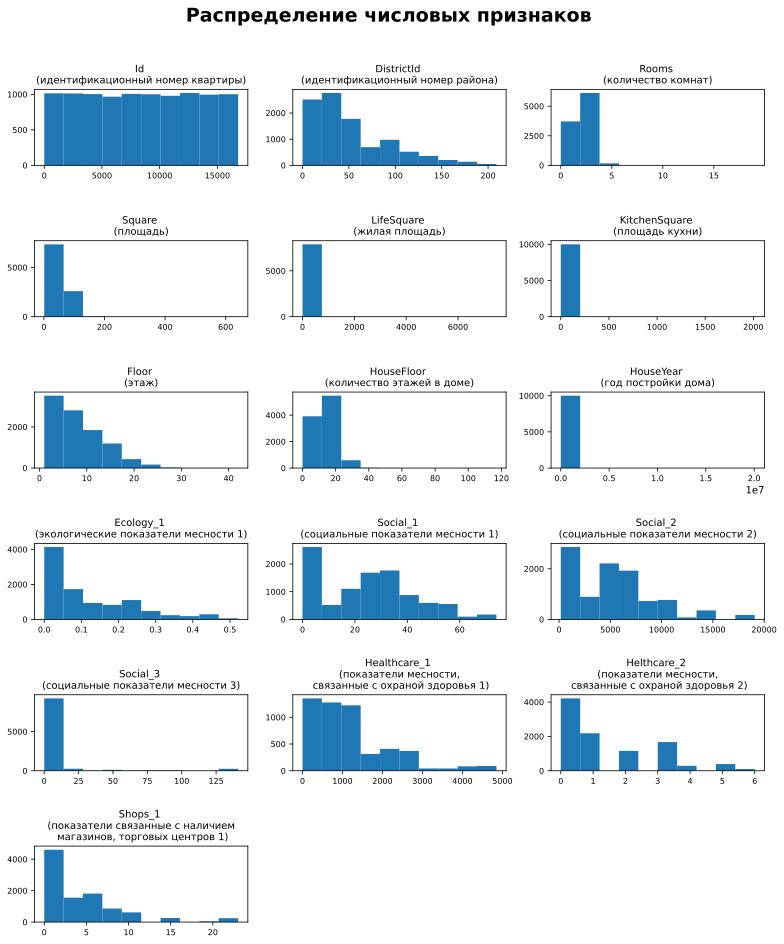

In [17]:
visualization_numerical_characteristics()

#### Визуализируем распределение целевой переменной <a class='anchor' id='target_visual'>

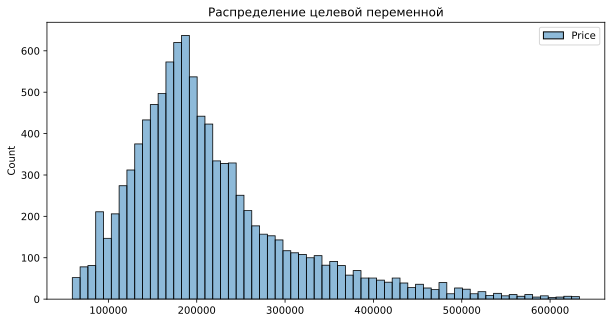

In [18]:
plt.figure(figsize = (10, 5))
plt.title('Распределение целевой переменной')
sns.histplot(y)

plt.show()

#### Визуализируем распределение строковых признаков <a class='anchor' id='char_visual'>

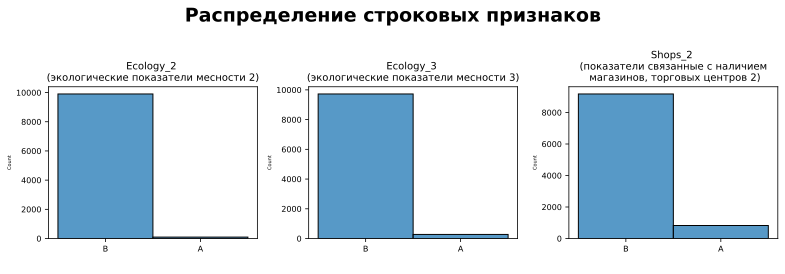

In [19]:
# Задаём размеры полотна [ширина, длина]
plt.figure(figsize=[11, 6])

# Общий заголовок для всех графиков
plt.suptitle('Распределение строковых признаков', 
              y=1.005, 
              fontsize=19, 
              fontweight='bold')
index_plt = 1
# Добавляем графики на полотно (3 шт. в одном ряду)
for col in str_cols:
    plt.subplot(2, 3, index_plt)
    # Заголовок для графика
    plt.title(f'{col} \n({translate_col[col]})', fontsize=10)
    # Задаём размер шривта и угол поворота текста для осей X и Y
    plt.xticks(fontsize=8, rotation=0)
    plt.yticks(fontsize=8, rotation=0)
    # Убираем подпись оси X
    plt.xlabel(' ')
    # Делаем размер шрифта по Y=5, не уберая название оси
    plt.ylabel('', fontsize=5)
    # Отрисовываем гистограмму
    sns.histplot(X[col])
    index_plt += 1

# Автоматически уместить все элементы на полотне    
plt.tight_layout()

# Вывести графики на экран
plt.show()

### Предобработка признаков <a class='anchor' id='predobrabotka'>

#### Посмотрим какие признаки имеют выбросы <a class='anchor' id='vibros'>

In [20]:
def emission_test(ds, col_test, threshold_val=3):
    '''
    Функция проводит тестирование столбцов на выбросы методом Z-score.
    
    :param ds: исследуемый датасет,
    :param col_test: список колонок,
    :param threshold_val: пороговое значение Z-score,
    :return: текстовый отчет и список выбросов.
    '''
    result = ''
    NUM = 2  # количество цифр после запятой
    outliers_list = [] # лист выбросов
    for col in col_test:
        # Вычисление Z-score
        z = np.abs(stats.zscore(ds[col]))
        # Установка порогового значения Z-score
        threshold = 3
        # Выявление выбросов на основе Z-score
        outliers = ds[col][z > threshold]
        
        if len(outliers) > 0:
            outliers_list.append(outliers)
            
            result += f'В столбце {col} ({translate_col[col]}),\n{len(outliers)} выбросов. Mean: {round(ds[col].mean(), NUM)}, ' \
            f'Min: {round(ds[col].min(), NUM)}, Max: {round(ds[col].max(), NUM)}, ' \
            f'Moda: {round(ds[col].mode()[0], NUM)}, Median: {round(ds[col].median(), NUM)} \n\n'
    
    return f'Выбросов нет. ' if result == '' else result, outliers_list

In [21]:
# Выведем признаки которые имеют выбросы
text_outliers, outliers = emission_test(ds=X, col_test=num_cols)

In [22]:
# Выведем текстовый отчёт по выбросам
print(text_outliers)

В столбце DistrictId (идентификационный номер района),
88 выбросов. Mean: 50.4, Min: 0, Max: 209, Moda: 27, Median: 36.0 

В столбце Rooms (количество комнат),
22 выбросов. Mean: 1.89, Min: 0.0, Max: 19.0, Moda: 2.0, Median: 2.0 

В столбце Square (площадь),
93 выбросов. Mean: 56.32, Min: 1.14, Max: 641.07, Moda: 1.14, Median: 52.51 

В столбце KitchenSquare (площадь кухни),
6 выбросов. Mean: 6.27, Min: 0.0, Max: 2014.0, Moda: 1.0, Median: 6.0 

В столбце Floor (этаж),
66 выбросов. Mean: 8.53, Min: 1, Max: 42, Moda: 4, Median: 7.0 

В столбце HouseFloor (количество этажей в доме),
23 выбросов. Mean: 12.61, Min: 0.0, Max: 117.0, Moda: 17.0, Median: 13.0 

В столбце HouseYear (год постройки дома),
1 выбросов. Mean: 3990.17, Min: 1910, Max: 20052011, Moda: 1977, Median: 1977.0 

В столбце Ecology_1 (экологические показатели месности 1),
61 выбросов. Mean: 0.12, Min: 0.0, Max: 0.52, Moda: 0.01, Median: 0.08 

В столбце Social_2 (социальные показатели месности 2),
176 выбросов. Mean: 5352.1

#### Уберём выбросы <a class='anchor' id='del_outliers'>

In [23]:
def viev_outliers(outliers_list, col_name):
    '''
    Функция выводит строки датафрейма, в которых есть выбросы.
    
    :param outliers_list: список выбросов,
    :param col_name: название признака (фичи),
    :return: индексы выбросов.
    '''
    for item in outliers:
        if item.name == col_name:
            return item.index 

##### Фича 'HouseYear'

In [24]:
# Посмотрим даты, которые больше текущей даты 
X[X['HouseYear'] > datetime.now().year]

,Id,DistrictId,Rooms,Square,LifeSquare,KitchenSquare,Floor,HouseFloor,HouseYear,Ecology_1,Ecology_2,Ecology_3,Social_1,Social_2,Social_3,Healthcare_1,Helthcare_2,Shops_1,Shops_2
1497,10814,109,1.00,37.27,20.24,9.00,9,12.00,20052011,0.14,B,B,30,6141,10,262.00,3,6,B
4189,11607,147,2.00,44.79,28.36,5.00,4,9.00,4968,0.32,B,B,25,4756,16,2857.00,5,8,B


**Изменения:**

In [25]:
# Заменим все года постройки, которые больше текущего года на моду
X.loc[X['HouseYear'] > datetime.now().year, ['HouseYear']] = X['HouseYear'].mode()[0]

In [26]:
# Посмотрим статиску
X['HouseYear'].describe()

count   10000.00
mean     1984.86
std        18.41
min      1910.00
25%      1974.00
50%      1977.00
75%      2001.00
max      2020.00
Name: HouseYear, dtype: float64

In [27]:
# Посмотрим выбросы
print(emission_test(ds=X, col_test=['HouseYear'])[0])

В столбце HouseYear (год постройки дома),
19 выбросов. Mean: 1984.86, Min: 1910, Max: 2020, Moda: 1977, Median: 1977.0 




**Вывод:** Убрал слишком большие даты. Далее нужно будет убрать выбросы, функцией логорифмирования.

##### Фича 'Rooms'

In [28]:
# Посмотрим выбросы и цену
train_data.loc[viev_outliers(outliers, 'Rooms')]

,Id,DistrictId,Rooms,Square,LifeSquare,KitchenSquare,Floor,HouseFloor,HouseYear,Ecology_1,Ecology_2,Ecology_3,Social_1,Social_2,Social_3,Healthcare_1,Helthcare_2,Shops_1,Shops_2,Price
377,5927,57,10.00,59.06,36.22,10.00,22,22.00,2002,0.09,B,B,74,19083,2,NaN,5,15,B,317265.32
1422,4282,195,5.00,95.62,62.38,7.00,7,7.00,1940,0.02,B,B,17,3079,59,2890.00,0,8,B,479525.15
1454,8491,1,19.00,42.01,21.78,7.00,17,17.00,2014,0.01,B,B,1,264,0,NaN,0,1,B,78364.62
1503,1243,86,5.00,108.06,82.72,8.00,3,5.00,1942,0.16,B,A,31,7010,5,4508.00,3,7,B,310305.07
1982,5548,86,5.00,275.65,233.95,26.00,12,37.00,2011,0.16,B,A,31,7010,5,4508.00,3,7,B,455264.88
2170,14003,99,6.00,59.41,38.70,6.00,7,9.00,1969,0.03,B,B,66,10573,1,1322.00,3,8,B,229661.96
3268,8901,34,5.00,121.58,114.91,1.00,25,1.00,1977,0.07,B,B,53,13670,4,NaN,1,11,B,455446.39
3271,6358,27,5.00,42.00,NaN,0.00,5,12.00,1977,0.01,B,B,4,915,0,NaN,0,0,B,112693.64
4431,7594,53,5.00,39.91,39.39,1.00,5,1.00,1977,0.05,B,B,34,7759,0,229.00,1,3,B,206148.85
4487,13434,13,5.00,183.38,100.99,15.00,2,6.00,1997,0.09,B,B,74,19083,2,NaN,5,15,B,622888.83


In [29]:
# Посмотрим количесиво квартир с различными комнатами
X['Rooms'].value_counts()

Rooms
2.00     3880
1.00     3705
3.00     2235
4.00      150
5.00       18
0.00        8
10.00       2
19.00       1
6.00        1
Name: count, dtype: int64

In [30]:
# Посмотрим квартиры с 0 комнат и ценой
train_data.query('(Rooms == 0)')

,Id,DistrictId,Rooms,Square,LifeSquare,KitchenSquare,Floor,HouseFloor,HouseYear,Ecology_1,Ecology_2,Ecology_3,Social_1,Social_2,Social_3,Healthcare_1,Helthcare_2,Shops_1,Shops_2,Price
1397,12638,27,0.00,138.43,136.22,0.00,4,3.00,2016,0.08,B,B,11,3097,0,NaN,0,0,B,268394.74
1981,7917,27,0.00,212.93,211.23,0.00,2,3.00,2008,0.21,B,B,9,1892,0,NaN,0,1,B,302211.26
2269,7317,27,0.00,41.79,NaN,0.00,13,0.00,1977,0.21,B,B,9,1892,0,NaN,0,1,B,98129.98
3911,770,28,0.00,49.48,NaN,0.00,16,0.00,2015,0.12,B,B,30,6207,1,1183.00,1,0,B,217009.34
4366,456,6,0.00,81.49,NaN,0.00,4,0.00,1977,0.24,B,B,5,1564,0,540.00,0,0,B,212864.80
4853,3224,27,0.00,2.38,0.87,0.00,1,0.00,1977,0.02,B,B,2,469,0,NaN,0,0,B,126596.94
6149,3159,88,0.00,38.70,19.35,9.00,9,16.00,1982,0.13,B,B,43,8429,3,NaN,3,9,B,158998.11
8834,9443,27,0.00,87.76,85.13,0.00,5,15.00,1977,0.21,B,B,9,1892,0,NaN,0,1,B,219281.92


**Измения:**

In [31]:
# Создадим индексы строк в которых 5 и более комнат, а их площадь менее 100 или меньше одной комнаты
index_edit = X.query('(((Rooms >= 5) & (Square < 100)) | (Rooms < 1))').index
# Заменим аномальные значения на медиану
X.loc[index_edit, ['Rooms']] = X['Rooms'].median()

In [32]:
# Посмотрим статиску
X['Rooms'].describe()

count   10000.00
mean        1.89
std         0.81
min         1.00
25%         1.00
50%         2.00
75%         2.00
max         5.00
Name: Rooms, dtype: float64

In [33]:
# Посмотрим выбросы
print(emission_test(ds=X, col_test=['Rooms'])[0])

В столбце Rooms (количество комнат),
13 выбросов. Mean: 1.89, Min: 1.0, Max: 5.0, Moda: 2.0, Median: 2.0 




**Вывод:** Исправил число комнат с 0 и более 5. Далее нужно будет убрать выбросы, функцией логорифмирования.

##### Фича 'KitchenSquare'

In [34]:
# Посмотрим выбросы
X.loc[viev_outliers(outliers, 'KitchenSquare')]

,Id,DistrictId,Rooms,Square,LifeSquare,KitchenSquare,Floor,HouseFloor,HouseYear,Ecology_1,Ecology_2,Ecology_3,Social_1,Social_2,Social_3,Healthcare_1,Helthcare_2,Shops_1,Shops_2
1064,14656,62,1.00,47.10,46.45,2014.00,4,1.00,2014,0.07,B,B,2,629,1,NaN,0,0,A
2916,12390,72,3.00,97.49,99.32,96.00,22,25.00,2019,0.21,B,B,11,2398,2,1994.00,3,0,B
2969,7441,62,3.00,114.73,112.59,112.00,3,3.00,2015,0.07,B,B,2,629,1,NaN,0,0,A
4651,12552,58,3.00,116.41,113.11,112.00,3,3.00,2016,0.44,B,B,23,5735,3,1084.00,0,5,B
8584,14679,81,1.00,32.28,19.28,1970.00,6,1.00,1977,0.01,B,B,30,5285,0,645.00,6,6,B
9895,2737,27,3.00,123.43,125.81,123.00,5,10.00,2015,0.02,B,B,2,469,0,NaN,0,0,B


In [35]:
# Посмотрим какие кухни есть
X['KitchenSquare'].value_counts().sort_values()

KitchenSquare
48.00         1
29.00         1
60.00         1
63.00         1
31.00         1
73.00         1
123.00        1
39.00         1
27.00         1
1970.00       1
54.00         1
21.00         1
84.00         1
75.00         1
35.00         1
62.00         1
40.00         1
96.00         1
42.00         1
66.00         1
78.00         1
53.00         1
26.00         1
36.00         1
23.00         1
72.00         1
2014.00       1
51.00         2
37.00         2
32.00         2
25.00         2
43.00         2
30.00         2
41.00         2
58.00         2
112.00        2
22.00         3
2.00          4
18.00         6
19.00        11
17.00        12
20.00        14
16.00        16
3.00         22
15.00        31
4.00         39
14.00        51
13.00        67
11.00       233
12.00       249
7.00        609
0.00        697
9.00        843
6.00       1038
10.00      1075
5.00       1169
8.00       1306
1.00       2460
Name: count, dtype: int64

In [36]:
# Посмотрим квартиры без кухни
X.query('(KitchenSquare == 0)').sort_values(by='Square')

,Id,DistrictId,Rooms,Square,LifeSquare,KitchenSquare,Floor,HouseFloor,HouseYear,Ecology_1,Ecology_2,Ecology_3,Social_1,Social_2,Social_3,Healthcare_1,Helthcare_2,Shops_1,Shops_2
4853,3224,27,2.00,2.38,0.87,0.00,1,0.00,1977,0.02,B,B,2,469,0,NaN,0,0,B
8030,13265,1,3.00,4.82,79.77,0.00,6,17.00,1977,0.01,B,B,1,264,0,NaN,0,1,B
7767,6927,21,1.00,16.12,8.82,0.00,2,5.00,1965,0.19,B,B,47,8004,3,125.00,3,5,B
1891,13685,0,1.00,17.50,13.45,0.00,7,5.00,1961,0.32,B,B,25,4756,16,2857.00,5,8,B
9516,14236,0,1.00,19.93,15.54,0.00,2,5.00,1962,0.32,B,B,25,4756,16,2857.00,5,8,B
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1397,12638,27,2.00,138.43,136.22,0.00,4,3.00,2016,0.08,B,B,11,3097,0,NaN,0,0,B
9432,338,46,5.00,147.71,NaN,0.00,6,0.00,1977,0.15,B,B,16,3433,4,2643.00,4,5,B
8913,2603,30,3.00,162.59,164.53,0.00,2,3.00,1977,0.00,B,B,22,6398,141,1046.00,3,23,B
6201,10678,17,4.00,170.02,NaN,0.00,12,0.00,1977,0.09,B,B,23,4635,5,3300.00,2,4,B


In [37]:
# Посмотрим квартиры с кухней > 20
X.query('(KitchenSquare > 20)').sort_values(by='Square')

,Id,DistrictId,Rooms,Square,LifeSquare,KitchenSquare,Floor,HouseFloor,HouseYear,Ecology_1,Ecology_2,Ecology_3,Social_1,Social_2,Social_3,Healthcare_1,Helthcare_2,Shops_1,Shops_2
8584,14679,81,1.00,32.28,19.28,1970.00,6,1.00,1977,0.01,B,B,30,5285,0,645.00,6,6,B
5480,15781,10,1.00,35.81,19.95,35.00,6,14.00,1971,0.28,B,B,33,8667,2,NaN,0,6,B
3379,16781,27,1.00,36.14,36.71,36.00,19,19.00,2017,0.07,B,B,2,629,1,NaN,0,0,A
5149,13703,42,1.00,38.07,19.72,73.00,9,10.00,2006,0.16,B,B,21,5731,0,NaN,1,0,B
7088,6569,27,1.00,38.22,18.72,84.00,4,17.00,2018,0.01,B,B,4,915,0,NaN,0,0,B
1077,9690,27,1.00,40.08,37.83,37.00,18,19.00,2019,0.21,B,B,9,1892,0,NaN,0,1,B
4588,448,48,1.00,41.19,1.63,41.00,2,1.00,1977,0.04,B,B,46,9515,5,NaN,1,10,B
9111,6708,48,1.00,42.07,22.49,39.00,1,10.00,2010,0.04,B,B,46,9515,5,NaN,1,10,B
4142,15466,88,1.00,42.36,44.78,41.00,10,19.00,2016,0.13,B,B,43,8429,3,NaN,3,9,B
5849,11624,46,1.00,42.98,24.22,37.00,15,16.00,1983,0.19,B,B,31,6137,4,NaN,0,1,B


In [38]:
# Посмотрим квартиры с кухней > 35
X.query('(KitchenSquare > 35)').sort_values(by='Square')

,Id,DistrictId,Rooms,Square,LifeSquare,KitchenSquare,Floor,HouseFloor,HouseYear,Ecology_1,Ecology_2,Ecology_3,Social_1,Social_2,Social_3,Healthcare_1,Helthcare_2,Shops_1,Shops_2
8584,14679,81,1.00,32.28,19.28,1970.00,6,1.00,1977,0.01,B,B,30,5285,0,645.00,6,6,B
3379,16781,27,1.00,36.14,36.71,36.00,19,19.00,2017,0.07,B,B,2,629,1,NaN,0,0,A
5149,13703,42,1.00,38.07,19.72,73.00,9,10.00,2006,0.16,B,B,21,5731,0,NaN,1,0,B
7088,6569,27,1.00,38.22,18.72,84.00,4,17.00,2018,0.01,B,B,4,915,0,NaN,0,0,B
1077,9690,27,1.00,40.08,37.83,37.00,18,19.00,2019,0.21,B,B,9,1892,0,NaN,0,1,B
4588,448,48,1.00,41.19,1.63,41.00,2,1.00,1977,0.04,B,B,46,9515,5,NaN,1,10,B
9111,6708,48,1.00,42.07,22.49,39.00,1,10.00,2010,0.04,B,B,46,9515,5,NaN,1,10,B
4142,15466,88,1.00,42.36,44.78,41.00,10,19.00,2016,0.13,B,B,43,8429,3,NaN,3,9,B
5849,11624,46,1.00,42.98,24.22,37.00,15,16.00,1983,0.19,B,B,31,6137,4,NaN,0,1,B
5816,2271,27,1.00,43.29,42.84,40.00,12,11.00,2015,0.21,B,B,9,1892,0,NaN,0,1,B


In [39]:
# Посмотрим квантили
X['KitchenSquare'].quantile(0.975), X['KitchenSquare'].quantile(0.025)

(np.float64(13.0), np.float64(0.0))

In [40]:
# Посмотрим медиану
X['KitchenSquare'].median()

np.float64(6.0)

**Изменения:**

In [41]:
# Заменим все года постройки, которые больше текущего года на медиану
X.loc[X['KitchenSquare'] > 35, ['KitchenSquare']] = X['KitchenSquare'].median()

In [42]:
X['KitchenSquare'].describe()

count   10000.00
mean        5.71
std         3.97
min         0.00
25%         1.00
50%         6.00
75%         9.00
max        35.00
Name: KitchenSquare, dtype: float64

In [43]:
# Посмотрим выбросы
print(emission_test(ds=X, col_test=['KitchenSquare'])[0])

В столбце KitchenSquare (площадь кухни),
47 выбросов. Mean: 5.71, Min: 0.0, Max: 35.0, Moda: 1.0, Median: 6.0 




**Вывод:** Убрал только кухни больше 35 $м^{2}$. Без кухни или совсем маленькие - это может быть комуналка. Далее нужно будет убрать выбросы, функцией логорифмирования.

##### Фичи 'Square' и 'LifeSquare'

In [44]:
# Посмотрим выбросы
X.loc[viev_outliers(outliers, 'Square')].sort_values(by='Square')

,Id,DistrictId,Rooms,Square,LifeSquare,KitchenSquare,Floor,HouseFloor,HouseYear,Ecology_1,Ecology_2,Ecology_3,Social_1,Social_2,Social_3,Healthcare_1,Helthcare_2,Shops_1,Shops_2
1726,5284,27,4.00,119.91,78.52,13.00,8,12.00,2015,0.07,B,B,2,629,1,NaN,0,0,A
727,13690,76,3.00,120.54,68.23,11.00,6,14.00,2014,0.00,B,B,7,1660,39,1786.00,1,5,B
8944,3627,27,3.00,120.77,118.05,1.00,8,1.00,1977,0.07,B,B,2,629,1,NaN,0,0,A
4979,14973,125,3.00,120.86,65.76,19.00,7,10.00,1999,0.19,B,B,47,8004,3,125.00,3,5,B
5416,10558,169,4.00,120.88,73.40,12.00,14,17.00,2000,0.18,B,B,18,3594,4,192.00,1,5,B
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1981,7917,27,2.00,212.93,211.23,0.00,2,3.00,2008,0.21,B,B,9,1892,0,NaN,0,1,B
1982,5548,86,5.00,275.65,233.95,26.00,12,37.00,2011,0.16,B,A,31,7010,5,4508.00,3,7,B
4690,2307,102,1.00,409.43,410.64,10.00,4,4.00,2016,0.24,B,B,26,3889,6,705.00,3,6,B
4262,28,9,2.00,604.71,NaN,1.00,17,18.00,1977,0.16,B,B,25,5648,1,30.00,2,4,B


In [45]:
# Посмотрим количество уникальных площадей квартир
len(X['Square'].unique())

10000

In [46]:
# Посмотрим количество
X['Square'].value_counts().sort_values()

Square
47.98    1
65.68    1
44.95    1
53.35    1
39.65    1
        ..
64.56    1
42.53    1
48.37    1
39.44    1
41.77    1
Name: count, Length: 10000, dtype: int64

In [47]:
# Посмотрим количество
X['LifeSquare'].value_counts().sort_values()

LifeSquare
26.35    1
34.29    1
32.79    1
30.98    1
22.16    1
        ..
47.80    1
57.00    1
23.11    1
32.01    1
21.16    1
Name: count, Length: 7887, dtype: int64

In [48]:
# Посмотрим квартиры < 20 м
X.query('(Square < 20)')

,Id,DistrictId,Rooms,Square,LifeSquare,KitchenSquare,Floor,HouseFloor,HouseYear,Ecology_1,Ecology_2,Ecology_3,Social_1,Social_2,Social_3,Healthcare_1,Helthcare_2,Shops_1,Shops_2
212,1748,88,2.00,5.50,67.63,1.00,24,22.00,1977,0.13,B,B,43,8429,3,NaN,3,9,B
1316,11526,27,1.00,4.63,1.97,1.00,18,1.00,1977,0.01,B,B,4,915,0,NaN,0,0,B
1608,10202,6,1.00,2.60,4.60,1.00,3,25.00,2014,0.24,B,B,5,1564,0,540.00,0,0,B
1891,13685,0,1.00,17.50,13.45,0.00,7,5.00,1961,0.32,B,B,25,4756,16,2857.00,5,8,B
3166,15127,150,1.00,17.05,20.04,8.00,7,12.00,1982,0.30,B,B,52,10311,6,NaN,1,9,B
3280,10527,27,1.00,4.38,40.81,1.00,10,17.00,2013,0.21,B,B,9,1892,0,NaN,0,1,B
3413,9487,5,1.00,5.13,5.55,1.00,1,1.00,1977,0.15,B,B,16,3433,4,2643.00,4,5,B
3794,523,101,1.00,18.51,15.17,3.00,5,5.00,1970,0.23,A,B,41,6558,7,1548.00,3,2,B
4739,12676,81,3.00,13.78,15.99,7.00,4,5.00,1960,0.32,B,B,25,4756,16,2857.00,5,8,B
4853,3224,27,2.00,2.38,0.87,0.00,1,0.00,1977,0.02,B,B,2,469,0,NaN,0,0,B


In [49]:
# Посмотрим квартиры 1 м
X.query('(Square == 1)')

,Id,DistrictId,Rooms,Square,LifeSquare,KitchenSquare,Floor,HouseFloor,HouseYear,Ecology_1,Ecology_2,Ecology_3,Social_1,Social_2,Social_3,Healthcare_1,Helthcare_2,Shops_1,Shops_2


In [50]:
# Посмотрим квартиры в которых общая площадь меньше жилой площади
X.query('(Square < LifeSquare)')

,Id,DistrictId,Rooms,Square,LifeSquare,KitchenSquare,Floor,HouseFloor,HouseYear,Ecology_1,Ecology_2,Ecology_3,Social_1,Social_2,Social_3,Healthcare_1,Helthcare_2,Shops_1,Shops_2
28,8054,23,1.00,42.53,43.97,1.00,3,9.00,2014,0.03,B,B,0,168,0,NaN,0,0,B
44,10521,38,3.00,104.21,106.34,0.00,20,0.00,2017,0.06,B,B,15,2787,2,520.00,0,7,B
52,2301,1,2.00,61.40,65.22,0.00,17,22.00,2016,0.01,B,B,1,264,0,NaN,0,1,B
123,8753,25,3.00,85.95,89.80,1.00,4,3.00,2017,0.07,B,B,53,13670,4,NaN,1,11,B
153,9870,62,1.00,51.83,53.49,1.00,5,1.00,2015,0.07,B,B,2,629,1,NaN,0,0,A
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9884,41,30,2.00,59.02,59.44,12.00,5,5.00,2016,0.00,B,B,22,6398,141,1046.00,3,23,B
9889,12918,23,2.00,51.44,53.13,6.00,3,17.00,2017,0.01,B,B,1,388,0,NaN,0,0,B
9895,2737,27,3.00,123.43,125.81,6.00,5,10.00,2015,0.02,B,B,2,469,0,NaN,0,0,B
9902,14001,73,1.00,44.10,44.27,1.00,7,24.00,2014,0.04,B,B,37,6856,84,1940.00,2,5,B


In [51]:
# Посмотрим статистику
X['LifeSquare'].describe()

count   7887.00
mean      37.20
std       86.24
min        0.37
25%       22.77
50%       32.78
75%       45.13
max     7480.59
Name: LifeSquare, dtype: float64

In [52]:
# Посмотрим квартиры с жилой площадью больше максимальной площади
X[X['LifeSquare'] > X['Square'].max()]

,Id,DistrictId,Rooms,Square,LifeSquare,KitchenSquare,Floor,HouseFloor,HouseYear,Ecology_1,Ecology_2,Ecology_3,Social_1,Social_2,Social_3,Healthcare_1,Helthcare_2,Shops_1,Shops_2
4328,16550,27,3.00,81.69,7480.59,1.00,9,17.00,2016,0.02,B,B,2,469,0,NaN,0,0,B


**Изменения:**

In [53]:
# Чтобы метраж у каждой квартиры, был уникальным - маловероятно. Округлим метраж до целых чисел
X['Square'] = X['Square'].apply(lambda x: round(x, 0))
X['LifeSquare'] = X['LifeSquare'].apply(lambda x: round(x, 0))

In [54]:
# Заменим экстримальные значения LifeSquare
X.loc[(X['LifeSquare'] > X['Square'].max()), ['LifeSquare']] = X['Square']

Оказывается есть квартиры 4,8 метра, не веришь смотри [видео](https://www.youtube.com/watch?v=15QK4Mg4wEU). Так, что это не выбросы. 

In [55]:
# Заменим совсем уж маленькую площадь
X.loc[(X['Square'] < 5), ['Square']] = 5

In [56]:
# Заменим не корректные значения Square на LifeSquare + KitchenSquare
X.loc[(X['Square'] < X['LifeSquare']), ['Square']] = X['LifeSquare'] + X['KitchenSquare']

In [57]:
# Заменим не корректные значения LifeSquare на Square - KitchenSquare
X.loc[(X['Square'] == X['LifeSquare']), ['LifeSquare']] = X['Square'] - X['KitchenSquare']

In [58]:
# Заменим недостающие значения LifeSquare или значения < 20.   LifeSquare = Square - KitchenSquare
X.loc[((X['LifeSquare'].isna()) | (X['LifeSquare'] < 20)), ['LifeSquare']] = X['Square'] - X['KitchenSquare']

In [59]:
# Посмотрим статистику Floor и HouseFloor
X.describe()

,Id,DistrictId,Rooms,Square,LifeSquare,KitchenSquare,Floor,HouseFloor,HouseYear,Ecology_1,Social_1,Social_2,Social_3,Healthcare_1,Helthcare_2,Shops_1
count,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,5202.00,10000.00,10000.00
mean,8383.41,50.40,1.89,56.61,42.75,5.71,8.53,12.61,1984.86,0.12,24.69,5352.16,8.04,1142.90,1.32,4.23
std,4859.02,43.59,0.81,21.67,21.94,3.97,5.24,6.78,18.41,0.12,17.53,4006.80,23.83,1021.52,1.49,4.81
min,0.00,0.00,1.00,5.00,4.00,0.00,1.00,0.00,1910.00,0.00,0.00,168.00,0.00,0.00,0.00,0.00
25%,4169.50,20.00,1.00,42.00,29.00,1.00,4.00,9.00,1974.00,0.02,6.00,1564.00,0.00,350.00,0.00,1.00
50%,8394.50,36.00,2.00,53.00,38.00,6.00,7.00,13.00,1977.00,0.08,25.00,5285.00,2.00,900.00,1.00,3.00
75%,12592.50,75.00,2.00,66.00,51.00,9.00,12.00,17.00,2001.00,0.20,36.00,7227.00,5.00,1548.00,2.00,6.00
max,16798.00,209.00,5.00,641.00,638.00,35.00,42.00,117.00,2020.00,0.52,74.00,19083.00,141.00,4849.00,6.00,23.00


In [60]:
# Посмотрим выбросы после чистки данных
print(emission_test(ds=X, col_test=['Square'])[0])
print(emission_test(ds=X, col_test=['LifeSquare'])[0])

В столбце Square (площадь),
91 выбросов. Mean: 56.61, Min: 5.0, Max: 641.0, Moda: 42.0, Median: 53.0 


В столбце LifeSquare (жилая площадь),
83 выбросов. Mean: 42.75, Min: 4.0, Max: 638.0, Moda: 21.0, Median: 38.0 




In [61]:
# Сформируем таблицу выбросов для 'Square' и 'LifeSquare'
outliers = emission_test(ds=X, col_test=['Square', 'LifeSquare'])[1]
# Посмотрим выбросы в Square после чистки данных
X.loc[viev_outliers(outliers, 'Square')].sort_values(by='Square')

,Id,DistrictId,Rooms,Square,LifeSquare,KitchenSquare,Floor,HouseFloor,HouseYear,Ecology_1,Ecology_2,Ecology_3,Social_1,Social_2,Social_3,Healthcare_1,Helthcare_2,Shops_1,Shops_2
358,6006,62,3.00,122.00,121.00,1.00,3,3.00,1977,0.07,B,B,2,629,1,NaN,0,0,A
2194,11599,23,1.00,122.00,121.00,1.00,2,2.00,1977,0.01,B,B,2,475,0,NaN,0,0,B
3268,8901,34,5.00,122.00,115.00,1.00,25,1.00,1977,0.07,B,B,53,13670,4,NaN,1,11,B
6489,10417,27,3.00,122.00,121.00,1.00,10,12.00,2019,0.07,B,B,2,629,1,NaN,0,0,A
5425,3377,85,3.00,122.00,121.00,1.00,4,17.00,2016,0.04,B,B,52,11217,1,2300.00,1,7,B
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1982,5548,86,5.00,276.00,234.00,26.00,12,37.00,2011,0.16,B,A,31,7010,5,4508.00,3,7,B
4690,2307,102,1.00,421.00,411.00,10.00,4,4.00,2016,0.24,B,B,26,3889,6,705.00,3,6,B
8437,15886,85,3.00,471.00,461.00,10.00,12,16.00,1998,0.04,B,B,52,11217,1,2300.00,1,7,B
4262,28,9,2.00,605.00,604.00,1.00,17,18.00,1977,0.16,B,B,25,5648,1,30.00,2,4,B


In [62]:
# Посмотрим выбросы в LifeSquare после чистки данных
X.loc[viev_outliers(outliers, 'LifeSquare')].sort_values(by='LifeSquare')

,Id,DistrictId,Rooms,Square,LifeSquare,KitchenSquare,Floor,HouseFloor,HouseYear,Ecology_1,Ecology_2,Ecology_3,Social_1,Social_2,Social_3,Healthcare_1,Helthcare_2,Shops_1,Shops_2
1784,13526,27,3.00,109.00,109.00,0.00,5,12.00,1977,0.07,B,B,2,629,1,NaN,0,0,A
9589,16638,38,1.00,110.00,109.00,1.00,4,1.00,1977,0.06,B,B,15,2787,2,520.00,0,7,B
9721,396,54,3.00,110.00,109.00,1.00,8,1.00,2015,0.01,B,B,30,5285,0,645.00,6,6,B
4987,5533,23,4.00,111.00,110.00,1.00,4,3.00,2015,0.03,B,B,0,168,0,NaN,0,0,B
8949,13178,30,1.00,112.00,111.00,1.00,9,8.00,2015,0.00,B,B,22,6398,141,1046.00,3,23,B
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
590,14990,23,2.00,269.00,264.00,5.00,6,5.00,1972,0.08,B,B,6,1437,3,NaN,0,2,B
4690,2307,102,1.00,421.00,411.00,10.00,4,4.00,2016,0.24,B,B,26,3889,6,705.00,3,6,B
8437,15886,85,3.00,471.00,461.00,10.00,12,16.00,1998,0.04,B,B,52,11217,1,2300.00,1,7,B
4262,28,9,2.00,605.00,604.00,1.00,17,18.00,1977,0.16,B,B,25,5648,1,30.00,2,4,B


**Вывод:** Почистил данные. Далее нужно будет убрать выбросы, функцией логорифмирования.

##### Фича 'HouseFloor' и 'Floor'

In [63]:
# Посмотрим сколько этажей у домов
X['HouseFloor'].sort_values().unique()

array([  0.,   1.,   2.,   3.,   4.,   5.,   6.,   7.,   8.,   9.,  10.,
        11.,  12.,  13.,  14.,  15.,  16.,  17.,  18.,  19.,  20.,  21.,
        22.,  23.,  24.,  25.,  26.,  27.,  28.,  29.,  30.,  31.,  32.,
        36.,  37.,  38.,  39.,  40.,  44.,  45.,  47.,  48.,  99., 117.])

In [64]:
# Посмотрим какие этажи у квартир
X['Floor'].sort_values().unique()

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 31, 32, 33, 37, 42])

In [65]:
# Посмотрим сколько квартир в которых, этаж квартиры больше, чем этажность дома
(X['Floor'] > X['HouseFloor']).sum()

np.int64(1825)

In [66]:
# Сформируем таблицу выбросов для 'HouseFloor' и 'Floor'
outliers = emission_test(ds=X, col_test=['HouseFloor', 'Floor'])[1]
# Посмотрим выбросы в HouseFloor 
X.loc[viev_outliers(outliers, 'HouseFloor')].sort_values(by='HouseFloor')

,Id,DistrictId,Rooms,Square,LifeSquare,KitchenSquare,Floor,HouseFloor,HouseYear,Ecology_1,Ecology_2,Ecology_3,Social_1,Social_2,Social_3,Healthcare_1,Helthcare_2,Shops_1,Shops_2
5452,11625,84,1.00,103.00,79.00,19.00,26,36.00,2012,0.01,B,B,30,5285,0,645.00,6,6,B
1982,5548,86,5.00,276.00,234.00,26.00,12,37.00,2011,0.16,B,A,31,7010,5,4508.00,3,7,B
3662,1102,54,3.00,101.00,52.00,20.00,20,37.00,2014,0.01,B,B,30,5285,0,645.00,6,6,B
1956,15157,54,1.00,106.00,83.00,17.00,26,37.00,2009,0.01,B,B,30,5285,0,645.00,6,6,B
5270,6327,146,3.00,75.00,46.00,9.00,11,37.00,2010,0.24,B,B,16,3893,27,NaN,3,10,B
6755,8296,146,1.00,86.00,72.00,0.00,37,38.00,2012,0.24,B,B,16,3893,27,NaN,3,10,B
6459,3302,30,2.00,105.00,86.00,6.00,25,39.00,2009,0.00,B,B,22,6398,141,1046.00,3,23,B
4525,14773,30,1.00,106.00,87.00,5.00,14,39.00,2010,0.00,B,B,22,6398,141,1046.00,3,23,B
5653,8500,31,1.00,81.00,25.00,29.00,6,40.00,2014,0.15,B,A,32,5889,10,830.00,4,1,B
5494,300,31,2.00,106.00,34.00,32.00,4,40.00,2013,0.15,B,A,32,5889,10,830.00,4,1,B


In [67]:
# Посмотрим экстримальные значения
X[X['HouseFloor'] < 1]

,Id,DistrictId,Rooms,Square,LifeSquare,KitchenSquare,Floor,HouseFloor,HouseYear,Ecology_1,Ecology_2,Ecology_3,Social_1,Social_2,Social_3,Healthcare_1,Helthcare_2,Shops_1,Shops_2
7,11993,74,2.00,80.00,80.00,0.00,14,0.00,1977,0.08,B,B,6,1437,3,NaN,0,2,B
23,6641,54,3.00,119.00,119.00,0.00,2,0.00,1977,0.01,B,B,30,5285,0,645.00,6,6,B
26,4378,27,3.00,107.00,107.00,0.00,17,0.00,2018,0.07,B,B,2,629,1,NaN,0,0,A
39,9371,23,2.00,61.00,61.00,0.00,16,0.00,1977,0.03,B,B,0,168,0,NaN,0,0,B
44,10521,38,3.00,106.00,106.00,0.00,20,0.00,2017,0.06,B,B,15,2787,2,520.00,0,7,B
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9707,12302,30,1.00,48.00,48.00,0.00,4,0.00,1977,0.00,B,B,22,6398,141,1046.00,3,23,B
9769,9384,59,3.00,99.00,99.00,0.00,14,0.00,1977,0.02,B,B,37,7687,11,176.00,5,5,B
9878,11441,62,2.00,72.00,72.00,0.00,5,0.00,1977,0.07,B,B,2,629,1,NaN,0,0,A
9908,3171,62,1.00,36.00,36.00,0.00,25,0.00,1977,0.07,B,B,2,629,1,NaN,0,0,A


In [68]:
# Посмотрим выбросы Floor
X.loc[viev_outliers(outliers, 'Floor')].sort_values(by='Floor')

,Id,DistrictId,Rooms,Square,LifeSquare,KitchenSquare,Floor,HouseFloor,HouseYear,Ecology_1,Ecology_2,Ecology_3,Social_1,Social_2,Social_3,Healthcare_1,Helthcare_2,Shops_1,Shops_2
315,14899,27,1.00,40.00,39.00,1.00,25,1.00,2015,0.07,B,B,2,629,1,NaN,0,0,A
501,15923,27,1.00,27.00,27.00,0.00,25,0.00,1977,0.07,B,B,2,629,1,NaN,0,0,A
1553,3185,109,2.00,54.00,33.00,8.00,25,25.00,2011,0.14,B,B,30,6141,10,262.00,3,6,B
1711,1445,27,3.00,51.00,51.00,0.00,25,25.00,1977,0.07,B,B,2,629,1,NaN,0,0,A
2109,15498,34,4.00,97.00,96.00,1.00,25,1.00,1977,0.07,B,B,53,13670,4,NaN,1,11,B
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
339,11563,8,1.00,50.00,42.00,0.00,32,32.00,2008,0.09,B,B,21,4346,2,165.00,1,2,B
3330,3298,31,1.00,58.00,22.00,10.00,32,40.00,1977,0.15,B,A,32,5889,10,830.00,4,1,B
8357,8016,31,1.00,60.00,24.00,10.00,33,40.00,1977,0.15,B,A,32,5889,10,830.00,4,1,B
6755,8296,146,1.00,86.00,72.00,0.00,37,38.00,2012,0.24,B,B,16,3893,27,NaN,3,10,B


In [69]:
# Посмотрим экстримальные значения Floor
X[X['Floor'] < 1]

,Id,DistrictId,Rooms,Square,LifeSquare,KitchenSquare,Floor,HouseFloor,HouseYear,Ecology_1,Ecology_2,Ecology_3,Social_1,Social_2,Social_3,Healthcare_1,Helthcare_2,Shops_1,Shops_2


**Изменения:**

In [70]:
def random_floor(floor):
    '''
    Процедура выбора случайной этажности дома для определённой квартиры.

    :param floor: этаж на которой расположена квартира,
    :return: случайная этажность дома или -1, если такого этажа не может быть.
    '''
    # Список с этажносстью домов
    house_floor_list = [5, 9, 14, 16, 24, 40, 48]
    # Веса выбора этажности (тоесть многоэтажки 40, 48 выпадают реже)
    weights = [5, 10, 20, 20, 10, 2, 1]
    # Скорректированные веса выбора этажности дома в зависимости от этажа текущей квартиры
    weights_corr = [weights[i] if house_floor_list[i] >= floor else 0 for i in range(len(weights))]
 
    if sum(weights_corr):
        house_floor = rnd.choices(house_floor_list, weights=weights_corr, k=1)
        return house_floor[0]
    else:
        return -1

In [71]:
# Заменим ошибочную этажность дома на релевантную 
X['HouseFloor'] = X['Floor'].apply(lambda x: random_floor(x))

In [72]:
# Посмотрим дома этажностью менее 5 и этаж квартиры больше этажности дома
X.query('(Floor > HouseFloor) | (HouseFloor < 5)')

,Id,DistrictId,Rooms,Square,LifeSquare,KitchenSquare,Floor,HouseFloor,HouseYear,Ecology_1,Ecology_2,Ecology_3,Social_1,Social_2,Social_3,Healthcare_1,Helthcare_2,Shops_1,Shops_2


In [73]:
# Посмотрим выбросы после чистки данных
print(emission_test(ds=X, col_test=['Floor'])[0])
print(emission_test(ds=X, col_test=['HouseFloor'])[0])

В столбце Floor (этаж),
66 выбросов. Mean: 8.53, Min: 1, Max: 42, Moda: 4, Median: 7.0 


В столбце HouseFloor (количество этажей в доме),
223 выбросов. Mean: 18.12, Min: 5, Max: 48, Moda: 16, Median: 16.0 




In [74]:
# Сформируем таблицу выбросов для 'Floor' и 'HouseFloor'
outliers = emission_test(ds=X, col_test=['Floor', 'HouseFloor'])[1]
# Посмотрим выбросы в Floor после чистки данных
X.loc[viev_outliers(outliers, 'Floor')].sort_values(by='Floor')

,Id,DistrictId,Rooms,Square,LifeSquare,KitchenSquare,Floor,HouseFloor,HouseYear,Ecology_1,Ecology_2,Ecology_3,Social_1,Social_2,Social_3,Healthcare_1,Helthcare_2,Shops_1,Shops_2
315,14899,27,1.00,40.00,39.00,1.00,25,48,2015,0.07,B,B,2,629,1,NaN,0,0,A
501,15923,27,1.00,27.00,27.00,0.00,25,48,1977,0.07,B,B,2,629,1,NaN,0,0,A
1553,3185,109,2.00,54.00,33.00,8.00,25,48,2011,0.14,B,B,30,6141,10,262.00,3,6,B
1711,1445,27,3.00,51.00,51.00,0.00,25,48,1977,0.07,B,B,2,629,1,NaN,0,0,A
2109,15498,34,4.00,97.00,96.00,1.00,25,48,1977,0.07,B,B,53,13670,4,NaN,1,11,B
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
339,11563,8,1.00,50.00,42.00,0.00,32,40,2008,0.09,B,B,21,4346,2,165.00,1,2,B
3330,3298,31,1.00,58.00,22.00,10.00,32,40,1977,0.15,B,A,32,5889,10,830.00,4,1,B
8357,8016,31,1.00,60.00,24.00,10.00,33,40,1977,0.15,B,A,32,5889,10,830.00,4,1,B
6755,8296,146,1.00,86.00,72.00,0.00,37,48,2012,0.24,B,B,16,3893,27,NaN,3,10,B


In [75]:
# Посмотрим выбросы в Floor после чистки данных
X.loc[viev_outliers(outliers, 'HouseFloor')].sort_values(by='HouseFloor')

,Id,DistrictId,Rooms,Square,LifeSquare,KitchenSquare,Floor,HouseFloor,HouseYear,Ecology_1,Ecology_2,Ecology_3,Social_1,Social_2,Social_3,Healthcare_1,Helthcare_2,Shops_1,Shops_2
46,1821,23,2.00,50.00,49.00,1.00,9,48,1977,0.03,B,B,0,168,0,NaN,0,0,B
158,16779,27,3.00,52.00,51.00,1.00,22,48,1977,0.07,B,B,2,629,1,NaN,0,0,A
177,9785,27,2.00,63.00,35.00,10.00,5,48,2015,0.07,B,B,2,629,1,NaN,0,0,A
311,16497,49,2.00,39.00,24.00,6.00,10,48,1965,0.02,B,B,24,5613,5,1340.00,2,5,B
315,14899,27,1.00,40.00,39.00,1.00,25,48,2015,0.07,B,B,2,629,1,NaN,0,0,A
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9684,14621,59,2.00,73.00,72.00,1.00,25,48,1977,0.02,B,B,37,7687,11,176.00,5,5,B
9810,12877,47,3.00,63.00,41.00,8.00,8,48,1979,0.10,B,B,23,4583,3,NaN,3,3,B
9846,7304,27,2.00,67.00,61.00,1.00,9,48,2014,0.02,B,B,2,469,0,NaN,0,0,B
9887,1418,41,2.00,55.00,35.00,8.00,10,48,1983,0.00,B,B,46,10309,1,240.00,1,16,B


**Вывод:** Заменил не корректную этажность домов. Далее нужно будет убрать выбросы, функцией логорифмирования.

##### Фича 'Healthcare_1'

In [76]:
# В фиче 'Healthcare_1' пропущено 50% записей - этот признак не информативен, удалим его
X.drop('Healthcare_1', axis=1, inplace=True)

#### Изменим тип признаков

##### Переведём строковые признаки в числовые

In [77]:
le = LabelEncoder()
# Пробежимся по столбцам датафрейма и преобразуем буквеное обозначение в цифровое
for col in str_cols:
    X[col] = le.fit_transform(X[col].astype(str))

In [78]:
X.dtypes

Id                 int64
DistrictId         int64
Rooms            float64
Square           float64
LifeSquare       float64
KitchenSquare    float64
Floor              int64
HouseFloor         int64
HouseYear          int64
Ecology_1        float64
Ecology_2          int64
Ecology_3          int64
Social_1           int64
Social_2           int64
Social_3           int64
Helthcare_2        int64
Shops_1            int64
Shops_2            int64
dtype: object

##### Переведём Id квартиры в строковый формат

In [79]:
X['Id'] = X['Id'].astype(str)
X['Id'].dtypes

dtype('O')

#### Поработаем с выбросами

In [80]:
# Выделим числовые признаки
num_cols = numeric_and_string_attributes(X)[0]

In [81]:
# Посмотрим выбросы
print(emission_test(ds=X, col_test=num_cols)[0])

В столбце DistrictId (идентификационный номер района),
88 выбросов. Mean: 50.4, Min: 0, Max: 209, Moda: 27, Median: 36.0 

В столбце Rooms (количество комнат),
13 выбросов. Mean: 1.89, Min: 1.0, Max: 5.0, Moda: 2.0, Median: 2.0 

В столбце Square (площадь),
91 выбросов. Mean: 56.61, Min: 5.0, Max: 641.0, Moda: 42.0, Median: 53.0 

В столбце LifeSquare (жилая площадь),
83 выбросов. Mean: 42.75, Min: 4.0, Max: 638.0, Moda: 21.0, Median: 38.0 

В столбце KitchenSquare (площадь кухни),
47 выбросов. Mean: 5.71, Min: 0.0, Max: 35.0, Moda: 1.0, Median: 6.0 

В столбце Floor (этаж),
66 выбросов. Mean: 8.53, Min: 1, Max: 42, Moda: 4, Median: 7.0 

В столбце HouseFloor (количество этажей в доме),
223 выбросов. Mean: 18.12, Min: 5, Max: 48, Moda: 16, Median: 16.0 

В столбце HouseYear (год постройки дома),
19 выбросов. Mean: 1984.86, Min: 1910, Max: 2020, Moda: 1977, Median: 1977.0 

В столбце Ecology_1 (экологические показатели месности 1),
61 выбросов. Mean: 0.12, Min: 0.0, Max: 0.52, Moda: 0.0

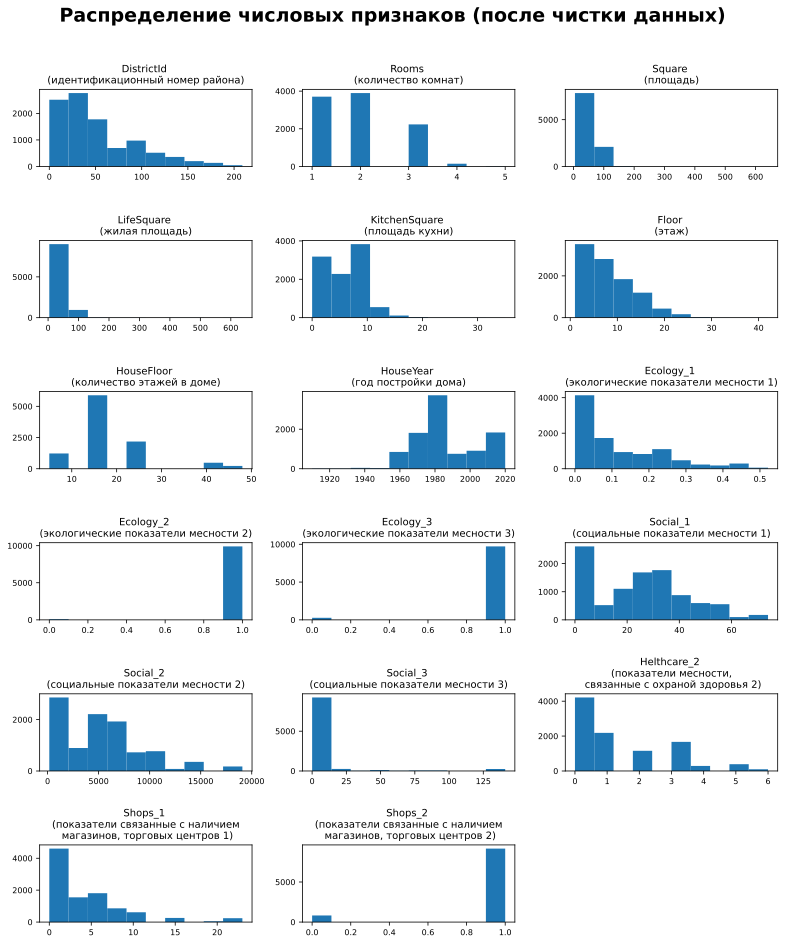

In [82]:
# Посмотрим визуально на графики числовых переменных
visualization_numerical_characteristics(dop_text='(после чистки данных)')

In [83]:
# Удалим выбросы с помощью логорифмической функции
for col in num_cols:
    X[col] = np.log1p(X[col])

In [84]:
# Посмотрим выбросы после логорифмирования
print(emission_test(ds=X, col_test=num_cols)[0])

В столбце Square (площадь),
50 выбросов. Mean: 4.0, Min: 1.79, Max: 6.46, Moda: 3.76, Median: 3.99 

В столбце LifeSquare (жилая площадь),
38 выбросов. Mean: 3.69, Min: 1.61, Max: 6.46, Moda: 3.09, Median: 3.66 

В столбце HouseYear (год постройки дома),
22 выбросов. Mean: 7.59, Min: 7.56, Max: 7.61, Moda: 7.59, Median: 7.59 

В столбце Ecology_1 (экологические показатели месности 1),
39 выбросов. Mean: 0.11, Min: 0.0, Max: 0.42, Moda: 0.01, Median: 0.07 

В столбце Ecology_2 (экологические показатели месности 2),
97 выбросов. Mean: 0.69, Min: 0.0, Max: 0.69, Moda: 0.69, Median: 0.69 

В столбце Ecology_3 (экологические показатели месности 3),
275 выбросов. Mean: 0.67, Min: 0.0, Max: 0.69, Moda: 0.69, Median: 0.69 

В столбце Social_3 (социальные показатели месности 3),
245 выбросов. Mean: 1.18, Min: 0.0, Max: 4.96, Moda: 0.0, Median: 1.1 

В столбце Shops_2 (показатели связанные с наличием
 магазинов, торговых центров 2),
825 выбросов. Mean: 0.64, Min: 0.0, Max: 0.69, Moda: 0.69, Medi

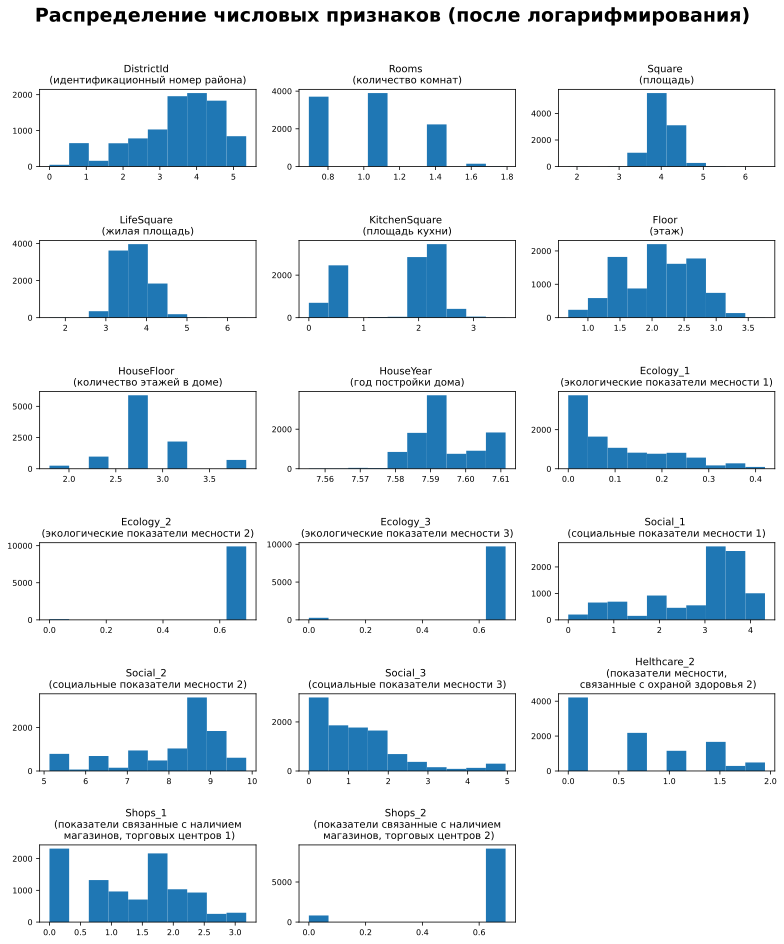

In [85]:
# Посмотрим визуально на графики числовых переменных, после логарифмирования
visualization_numerical_characteristics(dop_text='(после логарифмирования)')

**Вывод:** После логарифмирования, снизил среднее значение признаков, у некоторых признаков выбросы совсем исчезли.